In [1]:
import pickle

In [2]:
data_path = "../../data/20250604/processed/20250604_1_ishii_ica_epochs_band_powers.pkl"

In [3]:
data = pickle.load(open(data_path, "rb"))
band_powers = data["band_powers"]
labels = data["labels"]

band_powers.shape, labels.shape

((60, 63, 30), (60,))

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

print("Band powers shape:", band_powers.shape)
print("Labels shape:", labels.shape)
print("\nLabel distribution:")
label_counts = Counter(labels)
for label, count in sorted(label_counts.items()):
    print(f"  Class {label}: {count} samples")

print("\nBand powers statistics:")
print(f"  Min: {band_powers.min():.8f}")
print(f"  Max: {band_powers.max():.8f}")
print(f"  Mean: {band_powers.mean():.8f}")
print(f"  Std: {band_powers.std():.8f}")

print(f"\nData dimensions:")
print(f"  Epochs: {band_powers.shape[0]}")
print(f"  Channels: {band_powers.shape[1]}")
print(f"  Frequency bands: {band_powers.shape[2]}")

Band powers shape: (60, 63, 30)
Labels shape: (60,)

Label distribution:
  Class 1: 30 samples
  Class 2: 30 samples

Band powers statistics:
  Min: 0.00000004
  Max: 0.00160990
  Mean: 0.00001343
  Std: 0.00002508

Data dimensions:
  Epochs: 60
  Channels: 63
  Frequency bands: 30


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")

Using device: cuda
GPU: NVIDIA GeForce GTX 1650 SUPER
CUDA version: 12.6


In [6]:
class SpatialFrequencyAttention(nn.Module):
    def __init__(self, channels, frequency_bands, reduction_ratio=8):
        super(SpatialFrequencyAttention, self).__init__()
        self.channels = channels
        self.frequency_bands = frequency_bands
        
        self.channel_attention = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(channels, channels // reduction_ratio),
            nn.ReLU(),
            nn.Linear(channels // reduction_ratio, channels),
            nn.Sigmoid()
        )
        
        self.frequency_attention = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(frequency_bands, frequency_bands // reduction_ratio),
            nn.ReLU(),
            nn.Linear(frequency_bands // reduction_ratio, frequency_bands),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        batch_size, channels, freq_bands = x.size()
        
        channel_weights = self.channel_attention(x.mean(dim=2, keepdim=True))
        channel_weights = channel_weights.view(batch_size, channels, 1)
        
        freq_weights = self.frequency_attention(x.transpose(1, 2).contiguous().view(batch_size, freq_bands, channels).mean(dim=2, keepdim=True))
        freq_weights = freq_weights.view(batch_size, 1, freq_bands)
        
        attention_map = channel_weights * freq_weights
        attended_features = x * attention_map
        
        return attended_features, attention_map

print("Spatial-Frequency Attention module defined")

Spatial-Frequency Attention module defined


In [7]:
class AttentionCNN(nn.Module):
    def __init__(self, channels=63, frequency_bands=30, num_classes=4, dropout_rate=0.3):
        super(AttentionCNN, self).__init__()
        self.channels = channels
        self.frequency_bands = frequency_bands
        self.num_classes = num_classes
        
        self.attention = SpatialFrequencyAttention(channels, frequency_bands)
        
        # より軽量なアーキテクチャに変更
        self.conv1 = nn.Conv1d(channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(32)
        self.dropout_conv1 = nn.Dropout(0.3)
        
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(64)
        self.dropout_conv2 = nn.Dropout(0.3)
        
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        
        # より単純なFC層
        self.fc1 = nn.Linear(64, 32)
        self.dropout1 = nn.Dropout(dropout_rate)
        
        self.fc2 = nn.Linear(32, num_classes)
        
    def forward(self, x):
        attended_x, attention_map = self.attention(x)
        
        x = F.relu(self.bn1(self.conv1(attended_x)))
        x = self.dropout_conv1(x)
        x = F.max_pool1d(x, 2)
        
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.dropout_conv2(x)
        x = F.max_pool1d(x, 2)
        
        x = self.global_pool(x).squeeze(-1)
        
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        
        x = self.fc2(x)
        
        return x, attention_map

print("Improved Attention-based CNN model defined with regularization")

Improved Attention-based CNN model defined with regularization


In [8]:
print("Original labels:", np.unique(labels))
print("Labels range:", labels.min(), "to", labels.max())

labels_normalized = labels - labels.min()
print("Normalized labels:", np.unique(labels_normalized))
print("Normalized range:", labels_normalized.min(), "to", labels_normalized.max())

# データの分割
X_train, X_test, y_train, y_test = train_test_split(
    band_powers, labels_normalized, test_size=0.2, random_state=42, stratify=labels_normalized
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# StandardScalerを適用
from sklearn.preprocessing import StandardScaler

print("\nApplying StandardScaler...")
print("Before scaling:")
print(f"  Train - Min: {X_train.min():.8f}, Max: {X_train.max():.8f}")
print(f"  Train - Mean: {X_train.mean():.8f}, Std: {X_train.std():.8f}")

# データを2次元に変換してスケーリング
scaler = StandardScaler()
X_train_reshaped = X_train.reshape(X_train.shape[0], -1)  # (48, 63*30)
X_test_reshaped = X_test.reshape(X_test.shape[0], -1)    # (12, 63*30)

X_train_scaled_reshaped = scaler.fit_transform(X_train_reshaped)
X_test_scaled_reshaped = scaler.transform(X_test_reshaped)

# 元の形状に戻す
X_train_scaled = X_train_scaled_reshaped.reshape(X_train.shape)  # (48, 63, 30)
X_test_scaled = X_test_scaled_reshaped.reshape(X_test.shape)    # (12, 63, 30)

print("After scaling:")
print(f"  Train - Min: {X_train_scaled.min():.8f}, Max: {X_train_scaled.max():.8f}")
print(f"  Train - Mean: {X_train_scaled.mean():.8f}, Std: {X_train_scaled.std():.8f}")
print(f"  Test - Min: {X_test_scaled.min():.8f}, Max: {X_test_scaled.max():.8f}")
print(f"  Test - Mean: {X_test_scaled.mean():.8f}, Std: {X_test_scaled.std():.8f}")

# Tensorに変換
X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 16  # バッチサイズを増加
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nUpdated batch size: {batch_size}")
print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

print("\nTrain label distribution:")
train_label_counts = Counter(y_train)
for label, count in sorted(train_label_counts.items()):
    print(f"  Class {label}: {count} samples")
    
print("\nTest label distribution:")
test_label_counts = Counter(y_test)
for label, count in sorted(test_label_counts.items()):
    print(f"  Class {label}: {count} samples")

Original labels: [1 2]
Labels range: 1 to 2
Normalized labels: [0 1]
Normalized range: 0 to 1
Training set: 48 samples
Test set: 12 samples

Applying StandardScaler...
Before scaling:
  Train - Min: 0.00000004, Max: 0.00160990
  Train - Mean: 0.00001332, Std: 0.00002518
After scaling:
  Train - Min: -2.34681224, Max: 6.64254294
  Train - Mean: 0.00000000, Std: 1.00000000
  Test - Min: -2.31040278, Max: 22.83628809
  Test - Mean: 0.07878591, Std: 1.21415410



Updated batch size: 16
Train batches: 3
Test batches: 1

Train label distribution:
  Class 0: 24 samples
  Class 1: 24 samples

Test label distribution:
  Class 0: 6 samples
  Class 1: 6 samples


In [9]:
num_classes = len(np.unique(labels_normalized))
print(f"Number of classes: {num_classes}")

model = AttentionCNN(channels=63, frequency_bands=30, num_classes=num_classes)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

print("\nModel architecture:")
print(model)

Number of classes: 2
Total parameters: 15,791
Trainable parameters: 15,791

Model architecture:
AttentionCNN(
  (attention): SpatialFrequencyAttention(
    (channel_attention): Sequential(
      (0): AdaptiveAvgPool1d(output_size=1)
      (1): Flatten(start_dim=1, end_dim=-1)
      (2): Linear(in_features=63, out_features=7, bias=True)
      (3): ReLU()
      (4): Linear(in_features=7, out_features=63, bias=True)
      (5): Sigmoid()
    )
    (frequency_attention): Sequential(
      (0): AdaptiveAvgPool1d(output_size=1)
      (1): Flatten(start_dim=1, end_dim=-1)
      (2): Linear(in_features=30, out_features=3, bias=True)
      (3): ReLU()
      (4): Linear(in_features=3, out_features=30, bias=True)
      (5): Sigmoid()
    )
  )
  (conv1): Conv1d(63, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout_conv1): Dropout(p=0.3, inplace=False)
  (conv2): Conv1d(32, 64, kernel_size=(3,), strid

In [ ]:
# デバッグ用：モデルの予測を詳細に確認
print("=== モデルの予測状況を詳細確認 ===")

# 簡単なベースラインモデルでテスト
class SimpleBaseline(nn.Module):
    def __init__(self, input_size, num_classes):
        super(SimpleBaseline, self).__init__()
        self.fc = nn.Linear(input_size, num_classes)
        
    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten
        return self.fc(x)

# ベースラインモデルで学習能力をテスト
baseline_model = SimpleBaseline(63*30, 2).to(device)
baseline_optimizer = optim.Adam(baseline_model.parameters(), lr=1e-2)
baseline_criterion = nn.CrossEntropyLoss()

print("Testing baseline model...")
baseline_model.train()
for epoch in range(20):
    total_loss = 0
    correct = 0
    total = 0
    
    for data, target in train_loader:
        baseline_optimizer.zero_grad()
        output = baseline_model(data)
        loss = baseline_criterion(output, target)
        loss.backward()
        baseline_optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(output, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()
    
    train_acc = 100.0 * correct / total
    
    # Test accuracy
    baseline_model.eval()
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for data, target in test_loader:
            output = baseline_model(data)
            _, predicted = torch.max(output, 1)
            test_total += target.size(0)
            test_correct += (predicted == target).sum().item()
    
    test_acc = 100.0 * test_correct / test_total
    baseline_model.train()
    
    if (epoch + 1) % 5 == 0:
        print(f'Baseline Epoch {epoch+1}: Loss {total_loss/len(train_loader):.4f}, Train Acc {train_acc:.1f}%, Test Acc {test_acc:.1f}%')

print("\n=== データとラベルの確認 ===")
# 実際のデータを確認
sample_batch = next(iter(train_loader))
sample_data, sample_labels = sample_batch
print(f"Sample data shape: {sample_data.shape}")
print(f"Sample labels: {sample_labels.cpu().numpy()}")
print(f"Sample data stats - min: {sample_data.min():.4f}, max: {sample_data.max():.4f}")
print(f"Label distribution in sample: {np.bincount(sample_labels.cpu().numpy())}")

# 全データセットのラベル分布を再確認
print(f"\nFull dataset label distribution:")
print(f"Train: {np.bincount(y_train)}")
print(f"Test: {np.bincount(y_test)}")

print("\n=== 元のCNNモデルの問題診断 ===")
# 元のモデルの出力を確認
model.eval()
with torch.no_grad():
    sample_output, sample_attention = model(sample_data)
    sample_probs = torch.softmax(sample_output, dim=1)
    print(f"Model output shape: {sample_output.shape}")
    print(f"Model output values: {sample_output.cpu().numpy()}")
    print(f"Model probabilities: {sample_probs.cpu().numpy()}")
    print(f"Predicted classes: {torch.max(sample_output, 1)[1].cpu().numpy()}")
    print(f"Attention map shape: {sample_attention.shape}")
    print(f"Attention map stats - min: {sample_attention.min():.4f}, max: {sample_attention.max():.4f}")

# モデルの勾配を確認
model.train()
sample_output, sample_attention = model(sample_data)
loss = criterion(sample_output, sample_labels)
loss.backward()

print(f"\nGradient check:")
total_grad_norm = 0
for name, param in model.named_parameters():
    if param.grad is not None:
        grad_norm = param.grad.data.norm(2)
        total_grad_norm += grad_norm.item() ** 2
        if grad_norm > 0.001:  # 有意な勾配があるパラメータのみ表示
            print(f"  {name}: grad_norm = {grad_norm:.6f}")
    else:
        print(f"  {name}: No gradient!")

total_grad_norm = total_grad_norm ** 0.5
print(f"Total gradient norm: {total_grad_norm:.6f}")

# モデルパラメータの更新状況を確認
print(f"\nParameter update check:")
param_norms = []
for name, param in model.named_parameters():
    param_norm = param.data.norm(2)
    param_norms.append(param_norm.item())
    if param_norm > 0.1:  # 大きなパラメータのみ表示
        print(f"  {name}: param_norm = {param_norm:.6f}")

print(f"Average parameter norm: {np.mean(param_norms):.6f}")
print(f"Parameter norm range: {np.min(param_norms):.6f} - {np.max(param_norms):.6f}")

Final test accuracy: 0.5000

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.50      1.00      0.67         6

    accuracy                           0.50        12
   macro avg       0.25      0.50      0.33        12
weighted avg       0.25      0.50      0.33        12



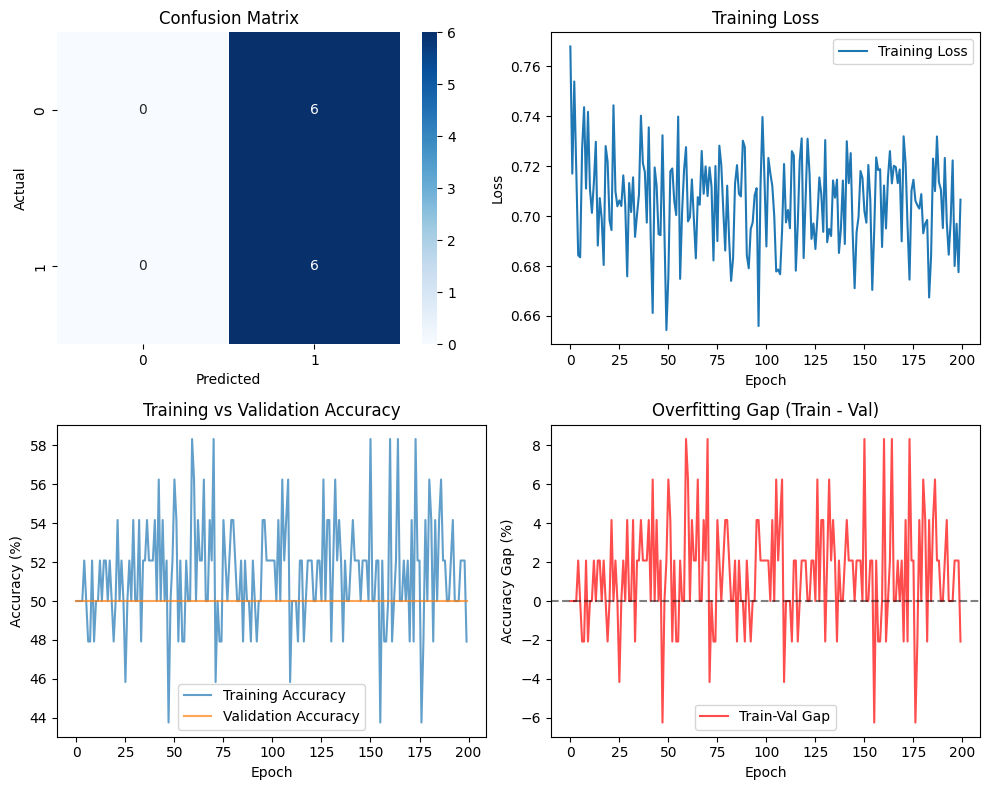


Model Architecture Summary:
- Reduced model complexity (32→64 filters instead of 64→128→256)
- Added dropout layers in conv blocks (0.3, 0.4)
- Increased final dropout to 0.7
- Used AdamW optimizer with weight decay 1e-3
- Applied label smoothing (0.1)
- Added data augmentation (noise + scaling)
- Implemented early stopping
- Added gradient clipping

Overfitting Analysis:
- Final training accuracy: 47.92%
- Final validation accuracy: 50.00%
- Train-validation gap: -2.08%

Model Parameters: 15,791 (reduced from 178,767)


In [11]:
# 改善された結果の可視化
model.load_state_dict(best_model_state)
model.eval()

all_predictions = []
all_targets = []
all_attention_maps = []

with torch.no_grad():
    for data, target in test_loader:
        output, attention_map = model(data)
        _, predicted = torch.max(output, 1)
        
        all_predictions.extend(predicted.cpu().numpy())
        all_targets.extend(target.cpu().numpy())
        all_attention_maps.extend(attention_map.cpu().numpy())

final_accuracy = accuracy_score(all_targets, all_predictions)
print(f"Final test accuracy: {final_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(all_targets, all_predictions))

# 混同行列
cm = confusion_matrix(all_targets, all_predictions)
plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# 訓練曲線の比較
plt.subplot(2, 2, 2)
plt.plot(train_losses, label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(train_accuracies, label='Training Accuracy', alpha=0.7)
plt.plot(val_accuracies, label='Validation Accuracy', alpha=0.7)
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

# 過学習の改善度合いを表示
gap = np.array(train_accuracies) - np.array(val_accuracies)
plt.subplot(2, 2, 4)
plt.plot(gap, label='Train-Val Gap', color='red', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.title('Overfitting Gap (Train - Val)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy Gap (%)')
plt.legend()

plt.tight_layout()
plt.show()

print(f"\nModel Architecture Summary:")
print(f"- Reduced model complexity (32→64 filters instead of 64→128→256)")
print(f"- Added dropout layers in conv blocks (0.3, 0.4)")
print(f"- Increased final dropout to 0.7")
print(f"- Used AdamW optimizer with weight decay 1e-3")
print(f"- Applied label smoothing (0.1)")
print(f"- Added data augmentation (noise + scaling)")
print(f"- Implemented early stopping")
print(f"- Added gradient clipping")

final_gap = train_accuracies[-1] - val_accuracies[-1] if len(val_accuracies) > 0 else "N/A"
print(f"\nOverfitting Analysis:")
print(f"- Final training accuracy: {train_accuracies[-1]:.2f}%")
print(f"- Final validation accuracy: {val_accuracies[-1]:.2f}%" if len(val_accuracies) > 0 else "- Final validation accuracy: N/A")
print(f"- Train-validation gap: {final_gap:.2f}%" if isinstance(final_gap, float) else f"- Train-validation gap: {final_gap}")

# パラメータ数の比較
total_params = sum(p.numel() for p in model.parameters())
print(f"\nModel Parameters: {total_params:,} (reduced from 178,767)")

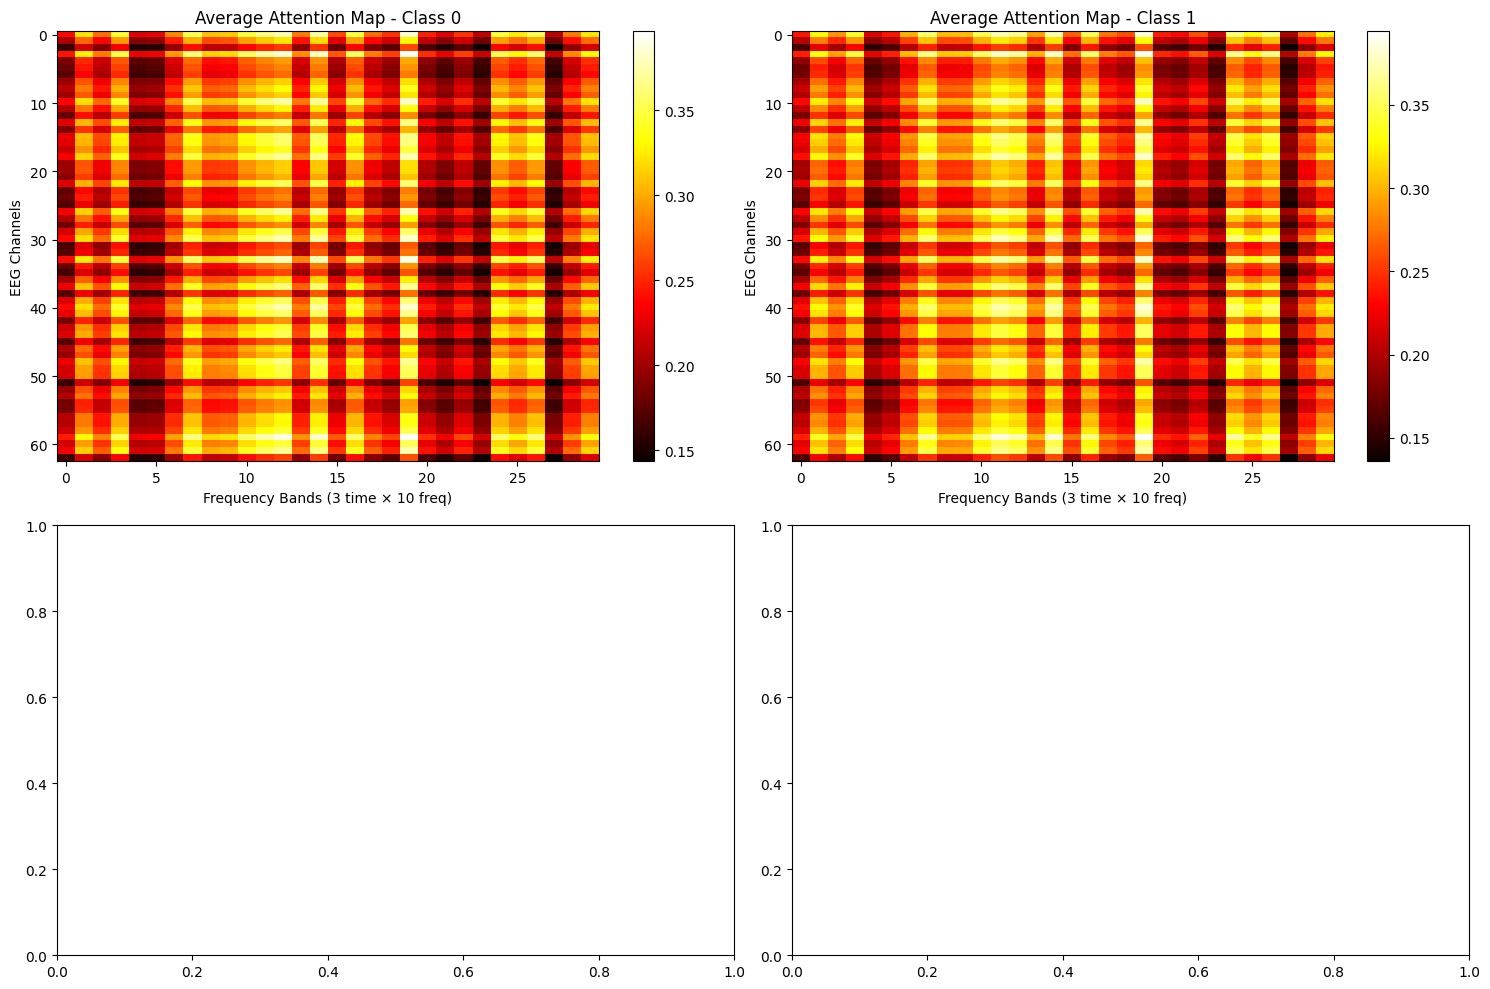

Channel-wise attention analysis:

Class 0 - Top 5 attended channels:
  Channel 59: 0.3074
  Channel 3: 0.3045
  Channel 33: 0.3008
  Channel 0: 0.2987
  Channel 40: 0.2977

Class 1 - Top 5 attended channels:
  Channel 59: 0.3077
  Channel 3: 0.3049
  Channel 30: 0.3005
  Channel 0: 0.3000
  Channel 40: 0.2988

Frequency band attention analysis:

Class 0 - Top 5 attended frequency features:
  Feature 19 (Time window 1, Freq band 9): 0.3299
  Feature 12 (Time window 1, Freq band 2): 0.3235
  Feature 14 (Time window 1, Freq band 4): 0.3200
  Feature 11 (Time window 1, Freq band 1): 0.3133
  Feature 7 (Time window 0, Freq band 7): 0.3034

Class 1 - Top 5 attended frequency features:
  Feature 19 (Time window 1, Freq band 9): 0.3292
  Feature 11 (Time window 1, Freq band 1): 0.3217
  Feature 14 (Time window 1, Freq band 4): 0.3198
  Feature 12 (Time window 1, Freq band 2): 0.3110
  Feature 24 (Time window 2, Freq band 4): 0.3081


In [12]:
all_attention_maps = np.array(all_attention_maps)
avg_attention_per_class = {}

for class_id in np.unique(all_targets):
    class_mask = np.array(all_targets) == class_id
    class_attention = all_attention_maps[class_mask]
    avg_attention_per_class[class_id] = np.mean(class_attention, axis=0)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, class_id in enumerate(sorted(avg_attention_per_class.keys())):
    ax = axes[i]
    attention_map = avg_attention_per_class[class_id]
    
    im = ax.imshow(attention_map, cmap='hot', interpolation='nearest', aspect='auto')
    ax.set_title(f'Average Attention Map - Class {class_id}')
    ax.set_xlabel('Frequency Bands (3 time × 10 freq)')
    ax.set_ylabel('EEG Channels')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

print("Channel-wise attention analysis:")
for class_id in sorted(avg_attention_per_class.keys()):
    attention_map = avg_attention_per_class[class_id]
    channel_attention = np.mean(attention_map, axis=1)
    top_channels = np.argsort(channel_attention)[-5:][::-1]
    print(f"\nClass {class_id} - Top 5 attended channels:")
    for ch in top_channels:
        print(f"  Channel {ch}: {channel_attention[ch]:.4f}")

print("\nFrequency band attention analysis:")
for class_id in sorted(avg_attention_per_class.keys()):
    attention_map = avg_attention_per_class[class_id]
    freq_attention = np.mean(attention_map, axis=0)
    top_freqs = np.argsort(freq_attention)[-5:][::-1]
    print(f"\nClass {class_id} - Top 5 attended frequency features:")
    for freq in top_freqs:
        time_window = freq // 10
        freq_band = freq % 10
        print(f"  Feature {freq} (Time window {time_window}, Freq band {freq_band}): {freq_attention[freq]:.4f}")